
**Use of AI Assistance- AI Acknowledgement**

For this assignment, I used Claude for assistance in translating R-specific functions and libraries such as dplyr and ggplot2 into their Python equivalents using pandas, numpy, matplotlibs. The AI helped me understand how R data structures and syntax map to Python so the analysis could run correctly in Google Colab. I also used AI to support parts of my coding process to make sure there were no errors. When errors did come up during testing, I used the AI to help me understand what the mistake was, why it occurred, and how to correct it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')


In [2]:
# We select fields for severity of charge, number of priors, demographics, age, sex,
# compas scores, and whether each person was accused of a crime within two years.
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))


7214


In [3]:
raw_data.head(10)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:

# There are a number of reasons remove rows because of missing data:
# * If the charge date of a defendants Compas scored crime was not within 30 days from
#   when the person was arrested, we assume that because of data quality reasons, that
#   we do not have the right offense.
# * In a similar vein, ordinary traffic offenses -- those with a c_charge_degree of 'O'
#   -- will not result in Jail time are removed (only two of them).
# * We filtered the underlying data from Broward county to include only those rows
#   representing people who had either recidivated in two years, or had at least two
#   years outside of a correctional facility.

df = raw_data[['age', 'c_charge_degree', 'race', 'age_cat',
               'score_text', 'sex', 'priors_count',
               'days_b_screening_arrest', 'decile_score', 'is_recid',
               'two_year_recid', 'c_jail_in', 'c_jail_out']].copy()

# ── Filtering ────────────────────────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']

# ── Type conversions ─────────────────────────────────────────────
df['c_jail_in']      = pd.to_datetime(df['c_jail_in'])
df['c_jail_out']     = pd.to_datetime(df['c_jail_out'])
df['two_year_recid'] = df['two_year_recid'].astype(int)
df['is_recid']       = df['is_recid'].astype(int)

# ── Derived factors with reference levels ─────────────────────────
df['crime_factor']  = df['c_charge_degree'].astype('category')
df['age_factor']    = pd.Categorical(df['age_cat'],
                          categories=['25 - 45', 'Greater than 45', 'Less than 25'])
df['race_factor']   = pd.Categorical(df['race'])
df['gender_factor'] = pd.Categorical(df['sex'], categories=['Male', 'Female'])
df['score_factor']  = np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore')

print(len(df))


6172


In [5]:
df.head(6)


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore
7,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,F,25 - 45,Other,Male,LowScore


In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}\n")
print(df.dtypes)


Rows: 6,172
Columns: 18

age                                 int64
c_charge_degree                    object
race                               object
age_cat                            object
score_text                         object
sex                                object
priors_count                        int64
days_b_screening_arrest           float64
decile_score                        int64
is_recid                            int64
two_year_recid                      int64
c_jail_in                  datetime64[ns]
c_jail_out                 datetime64[ns]
crime_factor                     category
age_factor                       category
race_factor                      category
gender_factor                    category
score_factor                       object
dtype: object


In [7]:
# Higher COMPAS scores are slightly correlated with a longer length of stay.
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
print(df['length_of_stay'].corr(df['decile_score']))


0.20747808478031807


In [8]:
print(df['age_cat'].value_counts().sort_index())


age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [9]:
print(df['race'].value_counts())


race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [10]:
print("Black defendants: %.2f%%" %           (3175 / 6172 * 100))
print("White defendants: %.2f%%" %           (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %        (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %           (31   / 6172 * 100))
print("Native American defendants: %.2f%%" % (11   / 6172 * 100))


Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
print(df['score_text'].value_counts())


score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [13]:
print(df['sex'].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
print(len(df[df['two_year_recid'] == 1]))

2809


In [ ]:
print(len(df[df['two_year_recid'] == 1]) / len(df) * 100)

45.51198963058976


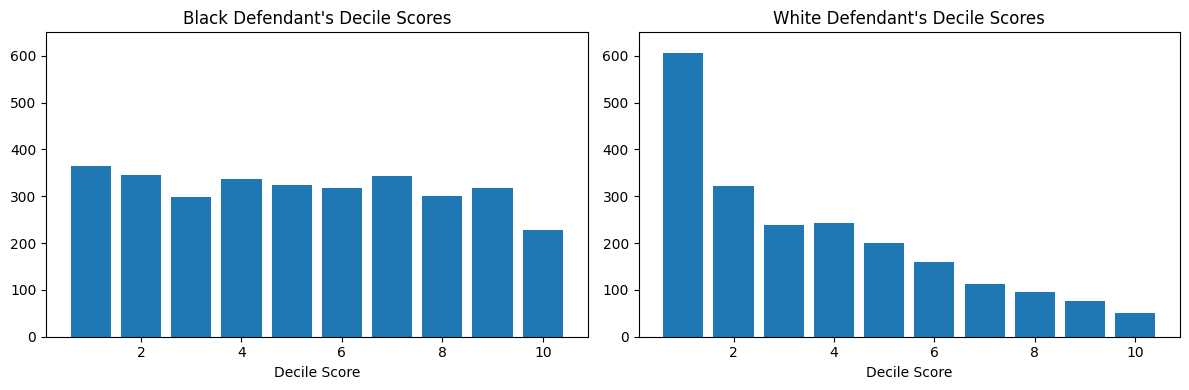

In [ ]:
# Judges are often presented with two sets of scores from the Compas system -- one that
# classifies people into High, Medium and Low risk, and a corresponding decile score.
# There is a clear downward trend in the decile scores as those scores increase for
# white defendants.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

black_df = df[df['race'] == 'African-American']
white_df = df[df['race'] == 'Caucasian']

# Black defendants
black_counts = black_df['decile_score'].value_counts().sort_index()
axes[0].bar(black_counts.index, black_counts.values)
axes[0].set_xlabel('Decile Score')
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")

# White defendants
white_counts = white_df['decile_score'].value_counts().sort_index()
axes[1].bar(white_counts.index, white_counts.values)
axes[1].set_xlabel('Decile Score')
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")

plt.tight_layout()
plt.show()

In [ ]:
print(pd.crosstab(df['decile_score'], df['race']))

race          African-American  Asian  Caucasian  Hispanic  Native American  \
decile_score                                                                  
1                          365     15        605       159                0   
2                          346      4        321        89                2   
3                          298      5        238        73                1   
4                          337      0        243        47                0   
5                          323      1        200        39                0   
6                          318      2        160        27                2   
7                          343      1        113        28                2   
8                          301      2         96        14                0   
9                          317      0         77        17                2   
10                         227      1         50        16                2   

race          Other  
decile_score         
1      

In [ ]:
# Racial Bias in Compas
#
# After filtering out bad rows, our first question is whether there is a significant
# difference in Compas scores between races. To do so we need to change some variables
# into factors, and run a logistic regression, comparing low scores to high scores.

# Binary outcome: 1 = HighScore, 0 = LowScore
df['score_factor_bin'] = (df['score_text'] != 'Low').astype(int)

model_glm = smf.logit(
    'score_factor_bin ~ C(sex, Treatment(reference="Male"))'
    ' + C(age_cat, Treatment(reference="25 - 45"))'
    ' + C(race, Treatment(reference="Caucasian"))'
    ' + priors_count'
    ' + C(c_charge_degree, Treatment(reference="F"))'
    ' + two_year_recid',
    data=df
).fit()

print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       score_factor_bin   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        03:59:00   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

In [ ]:
# Black defendants are 45% more likely than white defendants to receive a higher score
# correcting for the seriousness of their crime, previous arrests, and future criminal behavior.
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))
print(np.exp(0.47721) / (1 - control + (control * np.exp(0.47721))))

1.4528408658138932


In [ ]:
# Women are 19.4% more likely than men to get a higher score.
print(np.exp(0.22127) / (1 - control + (control * np.exp(0.22127))))

1.1947978508506671


In [ ]:
# Most surprisingly, people under 25 are 2.5 times as likely to get a higher score
# as middle aged defendants.
print(np.exp(1.30839) / (1 - control + (control * np.exp(1.30839))))

2.4961202077189455


In [ ]:
df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')

In [ ]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(df['pred_class'], df['two_year_recid'],
                         rownames=['Predicted'], colnames=['Actual'])
overall_cm = overall_cm.reindex(['No Recid', 'Recid'])
print(overall_cm)

TP = overall_cm.loc['Recid',    1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid',    0]
FN = overall_cm.loc['No Recid', 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────")

results = []
for race in df['race'].unique():
    group  = df[df['race'] == race]
    actual = group['two_year_recid']
    pred   = (group['pred_class'] == 'Recid').astype(int)
    TP = int(((pred == 1) & (actual == 1)).sum())
    TN = int(((pred == 0) & (actual == 0)).sum())
    FP = int(((pred == 1) & (actual == 0)).sum())
    FN = int(((pred == 0) & (actual == 1)).sum())
    n  = len(group)
    results.append({
        'race':      race,
        'n':         n,
        'TP':        TP,
        'TN':        TN,
        'FP':        FP,
        'FN':        FN,
        'Accuracy':  round((TP + TN) / n, 3),
        'Precision': round(TP / (TP + FP) if (TP + FP) > 0 else np.nan, 3),
        'Recall':    round(TP / (TP + FN) if (TP + FN) > 0 else np.nan, 3),
        'FPR':       round(FP / (FP + TN) if (FP + TN) > 0 else np.nan, 3),
        'FNR':       round(FN / (FN + TP) if (FN + TP) > 0 else np.nan, 3),
    })

race_metrics = pd.DataFrame(results).sort_values('n', ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))



── Confusion Matrix by Race ──────────────────────────────────────────
            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

caucasian_fpr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
caucasian_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - caucasian_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - caucasian_fnr).round(3)
print(disparity.to_string(index=False))




── FPR and FNR Disparity by Race ─────────────────────────────────────
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536
